In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import yfinance as yf

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score,precision_score

In [2]:
sp500 = yf.Ticker('^GSPC')

In [3]:
sp500 = sp500.history(period='max')

In [4]:
sp500.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,0.0,0.0
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0,0.0,0.0
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0,0.0,0.0
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0,0.0,0.0
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,0.0,0.0


In [5]:
sp500.shape

(24685, 7)

In [6]:
sp500.columns

Index(['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits'], dtype='object')

In [7]:
sp500.drop(columns=['Dividends', 'Stock Splits'], inplace=True)

In [8]:
sp500.shape

(24685, 5)

In [9]:
sp500.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 24685 entries, 1927-12-30 00:00:00-05:00 to 2026-04-10 00:00:00-04:00
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    24685 non-null  float64
 1   High    24685 non-null  float64
 2   Low     24685 non-null  float64
 3   Close   24685 non-null  float64
 4   Volume  24685 non-null  int64  
dtypes: float64(4), int64(1)
memory usage: 1.1 MB


In [10]:
sp500.describe()

,Open,High,Low,Close,Volume
count,24685.000000,24685.000000,24685.000000,24685.000000,2.468500e+04
mean,731.473424,735.674705,726.994843,731.618947,9.747525e+08
std,1255.547754,1262.185889,1248.354700,1255.742602,1.692396e+09
min,4.400000,4.400000,4.400000,4.400000,0.000000e+00
25%,24.959999,24.959999,24.959999,24.959999,1.600000e+06
50%,103.629997,104.449997,102.800003,103.620003,2.237000e+07
75%,1093.949951,1099.660034,1084.900024,1093.670044,1.189900e+09
max,7002.000000,7002.279785,6963.459961,6978.600098,1.145623e+10


## Data Preprocessing

In [11]:
sp500['Tommorow'] = sp500['Close'].shift(-1)

sp500.head()

,Open,High,Low,Close,Volume,Tommorow
Date,,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.760000
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0,17.719999
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0,17.549999
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0,17.660000
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.500000


In [12]:
sp500['Target'] = (sp500['Tommorow'] > sp500['Close']).astype(int)

sp500.head()

,Open,High,Low,Close,Volume,Tommorow,Target
Date,,,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.760000,1
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0,17.719999,0
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0,17.549999,0
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0,17.660000,1
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.500000,0


In [13]:
sp500.shape

(24685, 7)

In [14]:
# Removing very old data
sp500 = sp500.loc['1990-01-01':].copy()
sp500.head(3)

,Open,High,Low,Close,Volume,Tommorow,Target
Date,,,,,,,
1990-01-02 00:00:00-05:00,353.399994,359.690002,351.980011,359.690002,162070000,358.760010,0
1990-01-03 00:00:00-05:00,359.690002,360.589996,357.890015,358.760010,192330000,355.670013,0
1990-01-04 00:00:00-05:00,358.760010,358.760010,352.890015,355.670013,177000000,352.200012,0


In [15]:
sp500.shape

(9135, 7)

## EDA 

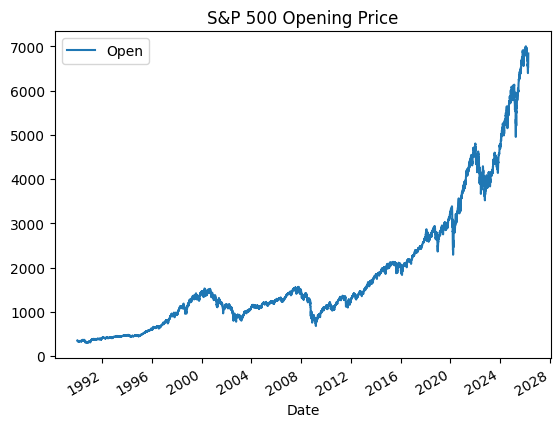

In [16]:
sp500.plot.line(y='Open', use_index=True)
plt.title('S&P 500 Opening Price')
plt.show()

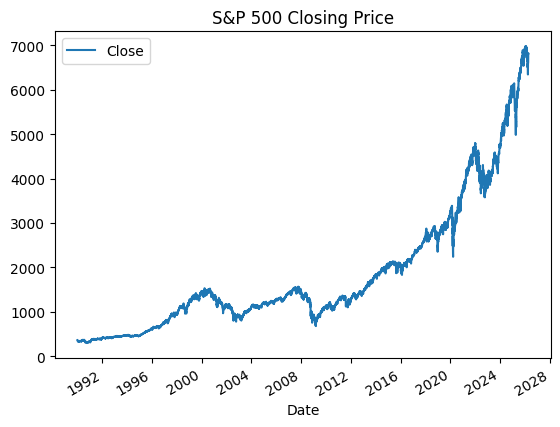

In [17]:
sp500.plot.line(y='Close', use_index=True)
plt.title('S&P 500 Closing Price')
plt.show()

## Dataset Split

In [18]:
train = sp500.iloc[:-100]
test = sp500.iloc[-100:]

train.shape, test.shape

((9035, 7), (100, 7))

In [19]:
predictors = ['Open', 'High', 'Low', 'Close', 'Volume']

## Model Building

In [20]:
model = RandomForestClassifier(n_estimators=100, min_samples_split=100, random_state=42)

model.fit(train[predictors], train['Target'])

RandomForestClassifier(min_samples_split=100, random_state=42)

In [21]:
preds = model.predict(test[predictors]) # Predictions

preds = pd.Series(preds, index=test.index)
preds

Date
2025-11-14 00:00:00-05:00    1
2025-11-17 00:00:00-05:00    1
2025-11-18 00:00:00-05:00    1
2025-11-19 00:00:00-05:00    1
2025-11-20 00:00:00-05:00    1
                            ..
2026-04-06 00:00:00-04:00    1
2026-04-07 00:00:00-04:00    1
2026-04-08 00:00:00-04:00    1
2026-04-09 00:00:00-04:00    1
2026-04-10 00:00:00-04:00    1
Length: 100, dtype: int64

In [22]:
print(f'Accuracy : {accuracy_score(test['Target'], preds):.3f}')

Accuracy : 0.630


In [23]:
print(classification_report(test['Target'], preds))

              precision    recall  f1-score   support

           0       0.63      0.56      0.59        48
           1       0.63      0.69      0.66        52

    accuracy                           0.63       100
   macro avg       0.63      0.63      0.63       100
weighted avg       0.63      0.63      0.63       100



In [24]:
combined = pd.concat([test['Target'], preds], axis=1)
combined.columns = ['Target', 'Predicted']
combined

,Target,Predicted
Date,,
2025-11-14 00:00:00-05:00,0,1
2025-11-17 00:00:00-05:00,0,1
2025-11-18 00:00:00-05:00,1,1
2025-11-19 00:00:00-05:00,0,1
2025-11-20 00:00:00-05:00,1,1
...,...,...
2026-04-06 00:00:00-04:00,1,1
2026-04-07 00:00:00-04:00,1,1
2026-04-08 00:00:00-04:00,1,1


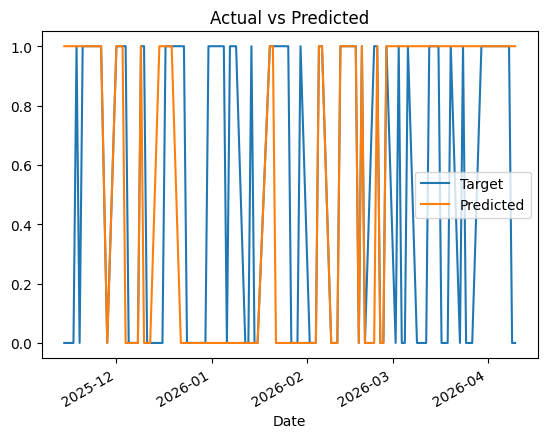

In [25]:
combined.plot()
plt.title('Actual vs Predicted')
plt.show()

## Predictions

In [26]:
def predict(train,test,predictors,model):

    model.fit(train[predictors], train['Target'])
    preds = model.predict(test[predictors])

    preds = pd.Series(preds, index=test.index)

    combined = pd.concat([test['Target'], preds], axis=1)
    combined.columns = ['Target', 'Predicted']
    
    return combined

In [27]:
def backtest(data, predictors, model, start=2500, step=250):

    all_predictions = []

    for i in range(start, data.shape[0], step):
        train = data.iloc[0:i].copy()
        test = data.iloc[i:i+step].copy()

        predictions = predict(train, test, predictors, model)
        all_predictions.append(predictions)

    return pd.concat(all_predictions)

In [28]:
predictions = backtest(sp500, predictors, model)

In [29]:
predictions['Predicted'].value_counts()

Predicted
0    3889
1    2746
Name: count, dtype: int64

In [30]:
print(f'Precision : {precision_score(predictions['Target'], predictions['Predicted']):.3f}')

Precision : 0.524


In [31]:
print(classification_report(predictions['Target'], predictions['Predicted']))

              precision    recall  f1-score   support

           0       0.45      0.57      0.51      3071
           1       0.52      0.40      0.46      3564

    accuracy                           0.48      6635
   macro avg       0.49      0.49      0.48      6635
weighted avg       0.49      0.48      0.48      6635



In [32]:
predictions['Target'].value_counts() / len(predictions)

Target
1    0.537151
0    0.462849
Name: count, dtype: float64

## Creating more Predictors

In [33]:
horizons = [2,5,60,250,1000] 
new_predictiors = []

for horizon in horizons:
    rolling_averages = sp500.rolling(window=horizon).mean()

    ratio_column = f'Close_Ratio_{horizon}'
    sp500[ratio_column] = sp500['Close'] / rolling_averages['Close']

    trend_column = f'Trend_{horizon}'
    sp500[trend_column] = sp500.shift(1).rolling(horizon).sum()['Target'] 

    new_predictiors += [ratio_column, trend_column]

In [34]:
sp500 = sp500.dropna()

In [35]:
sp500.head()

,Open,High,Low,Close,Volume,Tommorow,Target,Close_Ratio_2,Trend_2,Close_Ratio_5,Trend_5,Close_Ratio_60,Trend_60,Close_Ratio_250,Trend_250,Close_Ratio_1000,Trend_1000
Date,,,,,,,,,,,,,,,,,
1993-12-14 00:00:00-05:00,465.730011,466.119995,462.459991,463.059998,275050000,461.839996,0,0.997157,1.0,0.996617,1.0,1.000283,32.0,1.028047,127.0,1.176082,512.0
1993-12-15 00:00:00-05:00,463.059998,463.690002,461.839996,461.839996,331770000,463.339996,1,0.998681,0.0,0.995899,1.0,0.997329,32.0,1.025151,126.0,1.172676,512.0
1993-12-16 00:00:00-05:00,461.859985,463.980011,461.859985,463.339996,284620000,466.380005,1,1.001621,1.0,0.999495,2.0,1.000311,32.0,1.028274,127.0,1.176163,513.0
1993-12-17 00:00:00-05:00,463.339996,466.380005,463.339996,466.380005,363750000,465.850006,0,1.003270,2.0,1.004991,3.0,1.006561,32.0,1.034781,128.0,1.183537,514.0
1993-12-20 00:00:00-05:00,466.380005,466.899994,465.529999,465.850006,255900000,465.299988,0,0.999431,1.0,1.003784,2.0,1.005120,32.0,1.033359,128.0,1.181856,513.0


## Improving the Model

In [36]:
rf = RandomForestClassifier(n_estimators=200, min_samples_split=50, random_state=42)

In [37]:
def predict(train,test,predictors,model):

    model.fit(train[predictors], train['Target'])
    preds = model.predict_proba(test[predictors])[:,1]

    preds[preds >= 0.6] = 1
    preds[preds < 0.6] = 0

    preds = pd.Series(preds, index=test.index)

    combined = pd.concat([test['Target'], preds], axis=1)
    combined.columns = ['Target', 'Predicted']
    
    return combined

In [38]:
predictions = backtest(sp500, new_predictiors, rf)

In [39]:
predictions['Predicted'].value_counts()

Predicted
0.0    4793
1.0     841
Name: count, dtype: int64

In [40]:
print(f'Precision : {precision_score(predictions['Target'], predictions['Predicted']):.3f}')

Precision : 0.579


In [41]:
print(classification_report(predictions['Target'], predictions['Predicted']))

              precision    recall  f1-score   support

           0       0.46      0.86      0.60      2555
           1       0.58      0.16      0.25      3079

    accuracy                           0.48      5634
   macro avg       0.52      0.51      0.42      5634
weighted avg       0.52      0.48      0.41      5634



## Saving the Model

In [42]:
import pickle

In [43]:
pickle.dump(rf, open('rf_model.pkl', 'wb'))